# The Convolutional Classifier

A convnet used for image classification consists of two parts: a **convolutional base** and a **dense head**.


The base is used to **extract the features** from an image. It is formed primarily of layers performing the convolution operation, but often includes other kinds of layers as well. (You'll learn about these in the next lesson.)

The head is used to **determine the class** of the image. It is formed primarily of dense layers, but might include other layers like dropout.

What do we mean by visual feature? A feature could be a line, a color, a texture, a shape, a pattern -- or some complicated combination.

The whole process goes something like this:

<img src="https://storage.googleapis.com/kaggle-media/learn/images/UUAafkn.png" alt="The idea of feature extraction" width="500">

The features actually extracted look a bit different, but it gives the idea.

# Training the Classifier

The goal of the network during training is to learn two things:

1. which features to extract from an image (base),
2. which class goes with what features (head).

These days, convnets are rarely trained from scratch. More often, we **reuse the base of a pretrained model**. To the pretrained base we then **attach an untrained head**. In other words, we reuse the part of a network that has already learned to do *1. Extract features*, and attach to it some fresh layers to learn *2. Classify*.

<img src="https://storage.googleapis.com/kaggle-media/learn/images/E49fsmV.png" alt="Attaching a new head to a trained base" width="500">

Because the head usually consists of only a few dense layers, very accurate classifiers can be created from relatively little data.

Reusing a pretrained model is a technique known as **transfer learning**. It is so effective, that almost every image classifier these days will make use of it.

In [1]:
import os, warnings
import matplotlib.pyplot as plt
from matplotlib import gridspec

import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory



## Setting Random Seeds for Reproducibility

Neural networks use random operations throughout training (weight initialization, data shuffling, dropout, etc.). To ensure **reproducible results** - getting the same outcomes every time you run the code - we need to set random seeds.

The `set_seed()` function controls randomness in:
- **NumPy** operations (`np.random.seed`)
- **TensorFlow** operations (`tf.random.set_seed`)
- **Python** hash randomization (`PYTHONHASHSEED`)
- **TensorFlow deterministic operations** (`TF_DETERMINISTIC_OPS`)

Using the same seed (31415) ensures that each training run produces identical results, which is crucial for:
- Debugging and troubleshooting
- Fair model comparisons
- Sharing verifiable results with others

In [2]:
# Reproducability
def set_seed(seed=31415):
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'
set_seed(31415)


In [ ]:
# Set Matplotlib defaults
plt.rc('figure', autolayout=True)
plt.rc('axes', labelweight='bold', labelsize='large',
       titleweight='bold', titlesize=18, titlepad=10)
plt.rc('image', cmap='magma')
warnings.filterwarnings("ignore") # to clean up output cells

## Load Dataset

We'll use `image_dataset_from_directory` to load our Car vs Truck dataset. Let's understand the key parameters:

**Parameter Explanations:**

- **`labels='inferred'`**: Automatically creates labels from folder names. Since we have `Car/` and `Truck/` folders, it assigns:
  - Car = 0
  - Truck = 1

- **`label_mode='binary'`**: Uses binary classification (2 classes). For more classes, use `'categorical'`.

- **`image_size=[128, 128]`**: Resizes all images to 128×128 pixels. Neural networks require consistent input sizes. This size is:
  - Small enough for fast training
  - Large enough to preserve important features
  - Common choice for tutorials (you can use 224×224 or 256×256 for production)

- **`interpolation='nearest'`**: Resizing method. Options:
  - `'nearest'` - Fastest, lower quality
  - `'bilinear'` - Good balance (default)
  - `'bicubic'` - Highest quality, slower

- **`batch_size=64`**: Number of images processed together. Larger batches:
  - Train faster (GPU parallelization)
  - Use more memory
  - Common values: 16, 32, 64, 128

- **`shuffle=True`**: Randomly reorders images each epoch. Important for training:
  - Prevents learning order-dependent patterns
  - **True** for training
  - **False** for validation (for consistency)

- **`validation_split=0.2`**: Splits data into:
  - 80% training
  - 20% validation
  
- **`subset='training'/'validation'`**: Specifies which split to use.

- **`seed=31415`**: Ensures the same train/validation split every time (reproducibility).

In [3]:
# Load training and validation sets
ds_train_ = image_dataset_from_directory(
    '../data/Dataset',
    labels='inferred',
    label_mode='binary',
    image_size=[128, 128],
    interpolation='nearest',
    batch_size=64,
    shuffle=True,
    validation_split=0.2,
    subset='training',
    seed=31415
)

ds_valid_ = image_dataset_from_directory(
    '../data/Dataset',
    labels='inferred',
    label_mode='binary',
    image_size=[128, 128],
    interpolation='nearest',
    batch_size=64,
    shuffle=False,
    validation_split=0.2,
    subset='validation',
    seed=31415
)

Found 200 files belonging to 2 classes.
Using 160 files for training.
Found 200 files belonging to 2 classes.
Using 40 files for validation.


## Data Pipeline Optimization

Now we'll optimize the data pipeline for efficient training. This involves three key steps:

**1. Convert to Float (`convert_to_float`)**
- Image pixels are typically integers (0-255)
- Neural networks work better with floats (0.0-1.0)
- This normalization helps training converge faster

**2. Cache (`.cache()`)**
- Stores the dataset in memory after first epoch
- Subsequent epochs read from memory instead of disk
- **Much faster** but uses RAM
- Remove if dataset is too large for memory

**3. Prefetch (`.prefetch()`)**
- Loads the next batch while GPU processes current batch
- Prevents GPU from waiting idle
- `AUTOTUNE` automatically determines optimal buffer size
- **Critical for performance** - can double training speed

**Pipeline Flow:**
```
Load Image → Convert to Float → Cache → Prefetch → GPU Training
```

In [4]:
# Data Pipeline
def convert_to_float(image, label):
    image = tf.image.convert_image_dtype(image, dtype=tf.float32)
    return image, label

AUTOTUNE = tf.data.experimental.AUTOTUNE
ds_train = (
    ds_train_
    .map(convert_to_float)
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)
ds_valid = (
    ds_valid_
    .map(convert_to_float)
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)

## Step 2 - Define Pretrained Base

The most commonly used dataset for pretraining is [*ImageNet*](http://image-net.org/about-overview), a large dataset of many kind of natural images. Keras includes a variety models pretrained on ImageNet in its [`applications` module](https://www.tensorflow.org/api_docs/python/tf/keras/applications). The pretrained model we'll use is called **VGG16**.

In [5]:
# Load VGG16 pretrained on ImageNet
from tensorflow.keras.applications import VGG16

pretrained_base = VGG16(
    weights='imagenet',      # Use ImageNet pretrained weights
    include_top=False,       # Exclude the final classification layer
    input_shape=(128, 128, 3) # Match our image size (128x128 RGB)
)
pretrained_base.trainable = False  # Freeze the base (don't retrain)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 53s 1us/step


## Step 3 - Attach Head

Next, we attach the classifier head. For this example, we'll use a layer of hidden units (the first `Dense` layer) followed by a layer to transform the outputs to a probability score for class 1, `Truck`. The `Flatten` layer transforms the two dimensional outputs of the base into the one dimensional inputs needed by the head.

In [6]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    pretrained_base, # Pretrained convolutional base
    layers.Flatten(),     # Flatten the output of the convolutional base
    layers.Dense(6, activation='relu'), # Add a fully connected layer
    layers.Dense(1, activation='sigmoid') # Final output layer for binary classification
])



In [7]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['binary_accuracy'],
)

history = model.fit(
    ds_train,
    validation_data=ds_valid,
    epochs=30
)



Epoch 1/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step - binary_accuracy: 0.4812 - loss: 0.6779 - val_binary_accuracy: 0.7500 - val_loss: 0.7206
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 3s/step - binary_accuracy: 0.7875 - loss: 0.5676 - val_binary_accuracy: 0.4500 - val_loss: 0.8022
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step - binary_accuracy: 0.7250 - loss: 0.5087 - val_binary_accuracy: 0.6250 - val_loss: 0.7475
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 13s 5s/step - binary_accuracy: 0.8625 - loss: 0.4632 - val_binary_accuracy: 0.8000 - val_loss: 0.7282
Epoch 5/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 13s 4s/step - binary_accuracy: 0.8875 - loss: 0.4323 - val_binary_accuracy: 0.7500 - val_loss: 0.7524
Epoch 6/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 13s 4s/step - binary_accuracy: 0.8687 - loss: 0.4147 - val_binary_accuracy: 0.8250 - val_loss: 0.7361
Epoch 7/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 13s 4s/step - binary_accuracy: 0.9312 - loss: 0.3998 - val_binary_accuracy: 0.8750 - val_loss: 0.7256
Epoch 8/30
3/3 ━━━━━━━━━━━━━━━━━━━━

<Axes: title={'center': 'Accuracy'}>

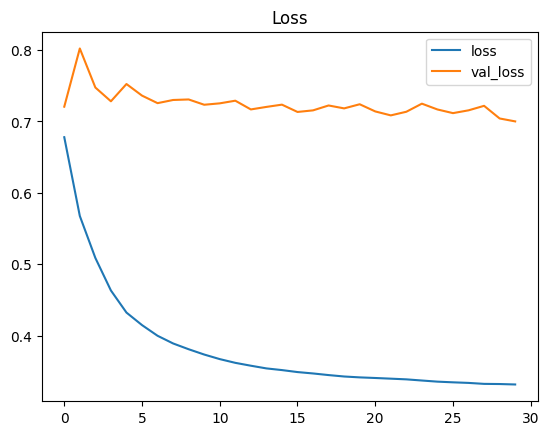

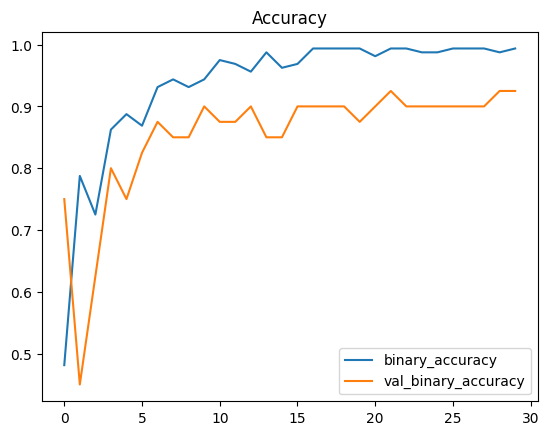

In [8]:
import pandas as pd

history_frame = pd.DataFrame(history.history)
history_frame.loc[:, ['loss', 'val_loss']].plot(title='Loss')
history_frame.loc[:, ['binary_accuracy', 'val_binary_accuracy']].plot(title='Accuracy')



# Conclusion

In this lesson, we learned about the structure of a convnet classifier: a **head** to act as a classifier atop of a **base** which performs the feature extraction.

The head, essentially, is an ordinary classifier like you learned about in the introductory course. For features, it uses those features extracted by the base. This is the basic idea behind convolutional classifiers: that we can attach a unit that performs feature engineering to the classifier itself.

This is one of the big advantages deep neural networks have over traditional machine learning models: given the right network structure, the deep neural net can learn how to engineer the features it needs to solve its problem.

For the next few lessons, we'll take a look at how the convolutional base accomplishes the feature extraction. Then, you'll learn how to apply these ideas and design some classifiers of your own.

## Understanding Loss vs Accuracy

When analyzing training results, it's important to understand the difference between **loss** and **accuracy**:

### Loss (Binary Cross-Entropy)
- Measures **how confident** the model is in its predictions
- Penalizes both wrong predictions AND uncertain predictions
- Lower values = better
- Continuous metric (can be any positive number)
- Example: Predicting "Truck" with 0.51 probability gives higher loss than predicting with 0.99 probability

### Accuracy
- Measures **how many predictions are correct**
- Simple threshold: prediction > 0.5 → Truck, ≤ 0.5 → Car
- Ignores confidence level
- Percentage (0-100%)
- Example: Both 0.51 and 0.99 predictions count as equally correct

### Interpreting Our Results

Looking at our plots:
- **Training accuracy**: ~100% (nearly perfect)
- **Validation accuracy**: ~92% (pretty good!)
- **Training loss**: ~0.34 (confident and correct)
- **Validation loss**: ~0.70 (less confident)

**What this tells us:**
The model gets 92% of validation images correct, but it's not very confident about those predictions. This gap between training and validation metrics is a sign of **overfitting** - the model has memorized the training data but doesn't generalize as confidently to new images.

**Key Insight:** You can have good accuracy but high loss if the model is correct but uncertain. This is why monitoring both metrics is important!